# Empirical Evaluation of Incremental LOF for Anomaly Detection in Data Streams

In [7]:
from river import metrics,  anomaly
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import deque
from sklearn.metrics import roc_auc_score

from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest 


## **1. Objective**
The goal of this study is to evaluate the effectiveness of Incremental LOF for anomaly detection in data streams, and to compare its performance against a stream-native baseline (Half-Space Trees). The study focuses on understanding under which conditions Incremental LOF performs well, and identifying its strengths and limitations in dynamic streaming environments.


## **Algorithm**
Incremental Local Outlier Factor (Incremental LOF)

## **Baseline**
Half-Space Trees (HST)

## **2. Problem Context**

Anomaly detection in data streams consists of identifying unusual or rare observations in a continuous flow of data. Unlike traditional settings, data arrives sequentially, cannot be stored entirely, and must be processed in real time.

This setting introduces several challenges:

- there is no clear train/test split,
- models must learn incrementally from a single pass over the data,
- and the underlying data distribution may change over time (concept drift).

As a result, algorithms must be efficient, adaptive, and capable of maintaining performance over time rather than on a fixed dataset

## **3. Algorithm: Incremental LOF**

### 3.1 Core Idea

Incremental LOF is an anomaly detection algorithm based on local density estimation.

The main idea is that a point is considered anomalous if its local density is significantly lower than that of its neighbors. Instead of looking at global distance, LOF compares each point with its local neighborhood.

This allows the detection of contextual anomalies, i.e., points that are unusual relative to their surrounding region but not necessarily globally distant from the dataset.

### 3.2 Streaming Behavior

Incremental LOF adapts the original LOF algorithm to a streaming setting by maintaining local structures incrementally.

For each point, the algorithm stores:

- its k-nearest neighbors (kNN)
- its reverse nearest neighbors (points that consider it a neighbor)
- its local reachability density (LRD)
- its LOF score

When a new point arrives:

- its neighborhood is computed,
- only the affected neighborhood is updated,
- LOF scores are recomputed locally instead of globally.

This allows the algorithm to approximate the behavior of batch LOF while maintaining efficiency in a streaming contex

### 3.3 Assumptions

Incremental LOF relies on several important assumptions:

- Local density is meaningful
    - Anomalies are defined as points that are sparse relative to their local neighborhood.
- Distance is meaningful
    - The quality of detection depends heavily on the distance metric and feature scaling.
- The choice of k is appropriate
    - Small k → sensitive but noisy
    - Large k → smoother but may hide anomalies

- No inherent drift handling
    - Although incremental, LOF does not include built-in mechanisms such as sliding windows or fading factors. As a result, past data may continue to influence the model even when the distribution changes.

## **4. Baseline: Half-Space Trees**

Half-Space Trees (HST) is an anomaly detection algorithm based on space partitioning.

Instead of using distances, HST recursively partitions the feature space into regions using random splits. Points that fall into regions with low mass (i.e., few observations) are considered anomalous.

This approach is inspired by isolation-based methods, where anomalies are easier to isolate than normal points.


In [ ]:
hst = anomaly.HalfSpaceTrees()

### 4.1 Why This Baseline

Half-Space Trees is chosen as a baseline because it represents a fundamentally different approach to anomaly detection in streams.

- It is stream-native, designed specifically for online processing
- It does not rely on distance or neighborhood structures
- It provides a strong contrast to LOF’s density-based perspective

This makes it particularly suitable for understanding when local density methods are advantageous compared to partition-based approaches.

| Aspect         | Incremental LOF      | Half-Space Trees          |
| -------------- | -------------------- | ------------------------- |
| Core idea      | Local density        | Space partitioning        |
| Uses distance  | Yes                  | No                        |
| Perspective    | Local                | Global-ish                |
| Structure      | Neighborhood graph   | Tree                      |
| Sensitivity    | Local anomalies      | Isolation-based anomalies |
| Drift handling | Weak (no forgetting) | Better (structure-based)  |
| Complexity     | Potentially high     | More stable               |



## **5. Research Question & Hypotheses**

The central research question of this study is:

    Under which conditions is Incremental LOF an effective anomaly detector in data streams compared to Half-Space Trees?

More specifically, we aim to understand how the performance of Incremental LOF is affected by:

- the nature of anomalies (local vs global),
- the presence of concept drift,
- and the choice of hyperparameters (especially k),

In comparison with a partition-based, stream-native method such as Half-Space Trees.

### 5.1 Hypotheses

Based on the assumptions of Incremental LOF and the differences with Half-Space Trees, we formulate the following hypotheses:

 **H1:** LOF performs better for local anomalies
   - Since LOF explicitly models local density, it should excel at detecting anomalies that are defined relative to their neighborhood.

 **H2:** LOF struggles under concept drift
   - Due to the lack of built-in forgetting mechanisms, past data may negatively influence current density estimates when the data distribution changes.

 **H3:** HST is more stable in evolving streams
   - As a partition-based and stream-native method, HST is expected to handle changes in data distribution more robustly.

 **H4:** LOF is sensitive to the choice of k
   - The number of neighbors directly impacts density estimation, making LOF sensitive to this parameter.

## **6. Experimental Design**

In data stream settings, traditional evaluation methods such as train/test splits are not applicable due to the sequential and potentially unbounded nature of the data.

Instead, we use prequential evaluation (predictive sequential evaluation).

For each incoming instance (𝑥𝑖,𝑦𝑖), the process is:

- The model makes a prediction (or anomaly score)
- The prediction is evaluated using the true label
- The model is updated with the new instance

This procedure evaluates how well the model performs on future unseen data over time.

Additionally, to better capture performance under evolving conditions, we consider:

- Sliding window evaluation, where only recent observations are considered
- Or fading factors, where older observations have less influence

These mechanisms allow us to assess how quickly the model adapts to changes in the data distribution

### 6.1 Metrics


To evaluate the performance of the anomaly detection algorithms, we use the following metrics:

- ROC AUC (Area Under the ROC Curve)
- Runtime (processing time per instance or cumulative time)
- Memory usage


In [20]:
roc_auc = metrics.ROCAUC()
#avg_precision = metrics.AveragePrecision()

## **7. Datasets**

To evaluate the behavior of Incremental LOF and Half-Space Trees under different conditions, we use two complementary datasets:

- a synthetic dataset, which allows full control over the data distribution and enables targeted testing of algorithm assumptions,
- a real-world dataset, which provides a realistic and noisy scenario for validation.

This combination ensures both interpretability and external validity of the results.

### 7.1 Synthetic Dataset

The synthetic dataset is designed to explicitly test the assumptions of Incremental LOF.

Using synthetic data allows:

- full control over cluster structure and density,
- controlled injection of anomalies,
- simulation of concept drift,
- and clear interpretation of results.

The stream is composed of multiple phases:

 1. Stable phase
    - well-defined dense clusters
    - a small number of injected anomalies
 2. Abrupt drift
    - cluster centers shift suddenly
 3. Gradual drift
    - clusters slowly move or change density
 4. Increased anomaly rate
    - higher proportion of anomalies

This design directly tests the hypotheses:

- LOF should perform well in stable local structures
- LOF should struggle under drift
- HST should be more stable over time

In [20]:
def generate_synthetic_stream(n_samples=4000, seed=42):
    import numpy as np
    import random

    np.random.seed(seed)
    random.seed(seed)

    stream = []

    # ---- Phase 1: Stable ----
    for _ in range(n_samples // 4):
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2)
            y = 1
        else:
            center = random.choice([(0, 0), (3, 3)])
            x = np.random.normal(loc=center, scale=0.5, size=2)
            y = 0

        stream.append(({"x1": x[0], "x2": x[1]}, y, "stable"))

    # ---- Phase 2: Abrupt drift ----
    for _ in range(n_samples // 4):
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2)
            y = 1
        else:
            center = random.choice([(6, 0), (0, 6)])
            x = np.random.normal(loc=center, scale=0.5, size=2)
            y = 0

        stream.append(({"x1": x[0], "x2": x[1]}, y, "abrupt"))

    # ---- Phase 3: Gradual drift ----
    for i in range(n_samples // 4):
        drift = i / (n_samples // 4)
        center = (3 * drift, 3 * drift)

        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2)
            y = 1
        else:
            x = np.random.normal(loc=center, scale=0.7, size=2)
            y = 0

        stream.append(({"x1": x[0], "x2": x[1]}, y, "gradual"))

    # ---- Phase 4: High anomaly ----
    for _ in range(n_samples // 4):
        if random.random() < 0.15:
            x = np.random.uniform(-6, 6, size=2)
            y = 1
        else:
            center = random.choice([(2, 2), (5, 5)])
            x = np.random.normal(loc=center, scale=0.6, size=2)
            y = 0

        stream.append(({"x1": x[0], "x2": x[1]}, y, "anomaly"))

    return stream

In [19]:
def stream_to_df(stream):
    data = []
    for x, y, phase in stream:
        data.append({
            "x1": x["x1"],
            "x2": x["x2"],
            "label": y,
            "phase": phase
        })
    return pd.DataFrame(data)



In [7]:
synthetic_stream = stream_to_df(generate_synthetic_stream())

#### **Dataset Visulization**

To validate the design of the synthetic dataset, we visualize each phase of the stream separately. This allows us to confirm that the data generation process reflects the intended experimental conditions.

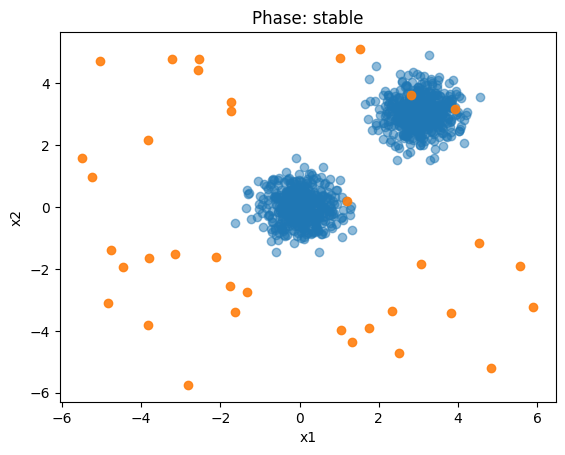

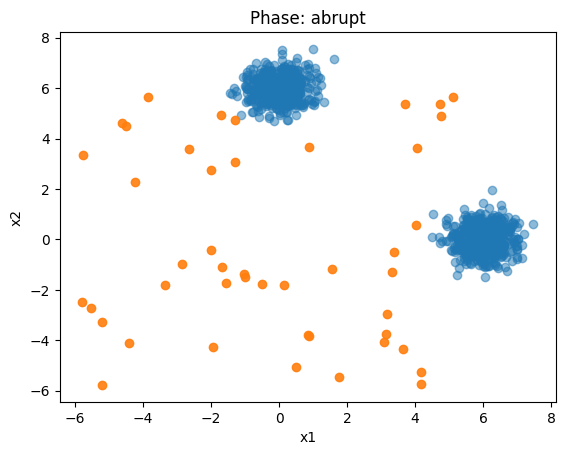

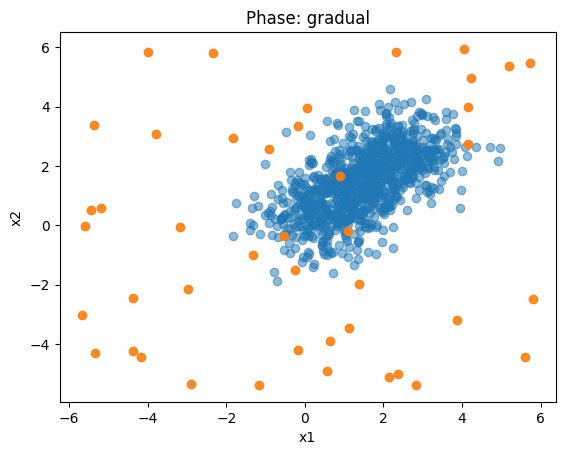

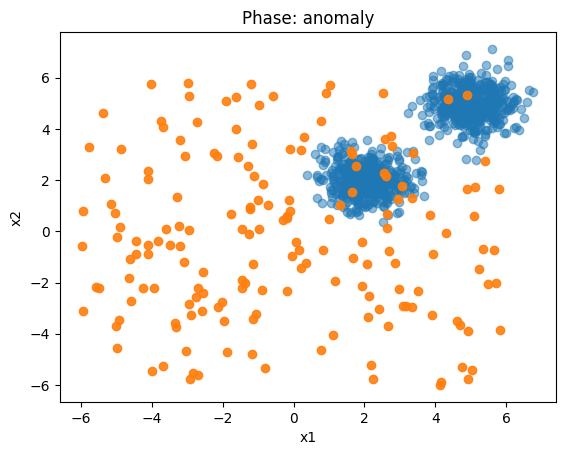

In [5]:
def plot_phase(df, phase_name):
    subset = df[df["phase"] == phase_name]

    normal = subset[subset["label"] == 0]
    anomaly = subset[subset["label"] == 1]

    plt.figure()
    plt.scatter(normal["x1"], normal["x2"], alpha=0.5)
    plt.scatter(anomaly["x1"], anomaly["x2"], alpha=0.9)
    plt.title(f"Phase: {phase_name}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

for phase in synthetic_stream["phase"].unique():
    plot_phase(synthetic_stream, phase)

**Phase 1: Stable clusters**

- The first phase shows two well-defined dense clusters with a small number of scattered anomalies.
- This represents a stationary environment where local density is meaningful.

- Implication : This is the ideal setting for Incremental LOF, as anomalies are clearly sparse relative to their local neighborhoods.

**Phase 2: Abrupt drift**

- In this phase, the cluster centers shift suddenly to new locations.
- The structure remains similar, but its position in the feature space changes abruptly.

- Implication: 
    - This tests how quickly each algorithm adapts to sudden distribution changes. 
    - Incremental LOF may struggle because previously learned neighborhoods become outdated.

**Phase 3: Gradual drift**

Here, the cluster progressively moves over time, creating a continuous transition in the data distribution.

- Implication:
    - This evaluates adaptation under smooth concept drift.
    - Algorithms without forgetting mechanisms may accumulate outdated information and degrade in performance.

**Phase 4: Increased anomaly rate**

This phase introduces a significantly higher number of anomalies, making the dataset more challenging.

- Implication:
    - This tests robustness under high anomaly contamination and class imbalance.
    - It also evaluates whether the models become less reliable when anomalies are more frequent.

These visualizations confirm that the synthetic dataset successfully reproduces controlled scenarios of stability, abrupt drift, gradual drift, and varying anomaly rates, enabling a systematic evaluation of the algorithms.

#### **Full Stream Evolution**

The full synthetic stream visualization shows the aggregation of all phases in a single view. 

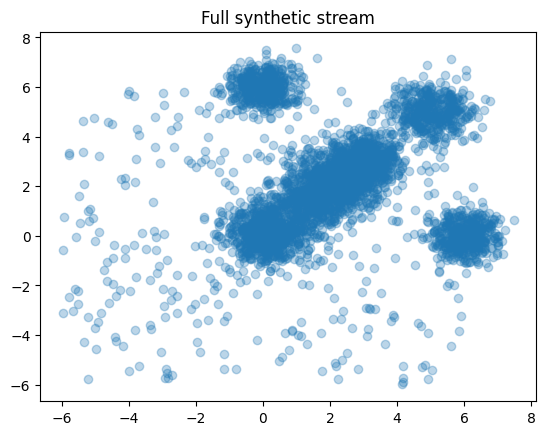

In [6]:
plt.figure()
plt.scatter(synthetic_stream["x1"], synthetic_stream["x2"], alpha=0.3)
plt.title("Full synthetic stream")
plt.show()


The plot reveals multiple cluster configurations corresponding to different stages of the stream, along with scattered anomalies distributed across the feature space.

We can observe:

- distinct cluster regions corresponding to different phases,
- overlapping structures due to gradual drift,
- and a significant number of anomalies spread across the space.

This confirms that the dataset combines stationary behavior, abrupt changes, gradual transitions, and varying anomaly densities within a single continuous stream.

#### **Full stream evolution over time**

Finnally, to better understand the temporal dynamics of the synthetic stream, we visualize the evolution of feature values over time.


This plot shows how the distribution of the data changes as new instances arrive, revealing different phases of the stream:

- an initial stable phase with consistent feature values,
- a sudden shift corresponding to abrupt drift,
- a smooth transition representing gradual drift,
- and a final phase with increased variability due to a higher anomaly rate.

This confirms that the synthetic dataset successfully simulates non-stationary behavior, which is a key challenge in data stream mining.

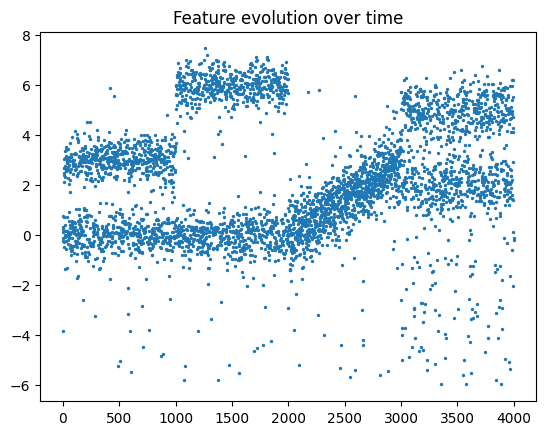

In [26]:
synthetic_stream["t"] = range(len(synthetic_stream))

plt.figure()
plt.scatter(synthetic_stream["t"], synthetic_stream["x1"], s=2)
plt.title("Feature evolution over time")
plt.show()

### 7.2 Real Dataset

To complement the synthetic dataset, we use a real-world anomaly detection dataset.

We choose the **Credit Card Fraud Detection** dataset, which is widely used for benchmarking anomaly detection methods.

This dataset is suitable because:

- it is highly imbalanced (very few fraud cases),
- it contains real-world noise and complexity,
- and it can be processed sequentially to simulate a data stream.

Using a real dataset allows us to validate whether the conclusions obtained from synthetic experiments generalize to practical scenarios.

In [27]:
def load_creditcard_stream(path):
    df = pd.read_csv(path)

    # Drop non-feature columns
    if "Time" in df.columns:
        df = df.drop(columns=["Time"])

    stream = []

    for _, row in df.iterrows():
        x = row.drop("Class").to_dict()
        y = int(row["Class"])  # 1 = fraud (anomaly), 0 = normal
        
        stream.append((x, y))

    return stream

In [28]:
stream = load_creditcard_stream("datasets/creditcard.csv")

#### **Class imbalance analysis**

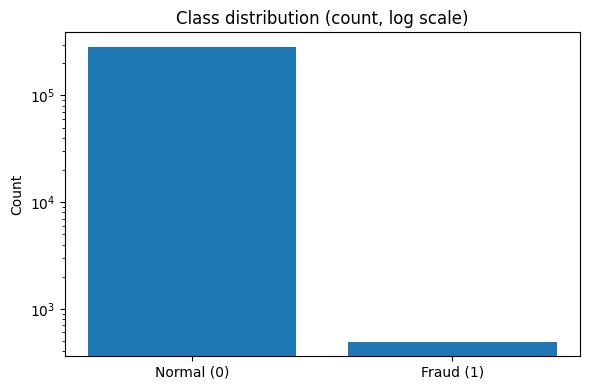

In [29]:
labels = pd.Series([y for _, y in stream])
counts = labels.value_counts().reindex([0, 1], fill_value=0)
perc = counts / counts.sum() * 100

plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Fraud (1)"], counts.values)
plt.yscale("log")
plt.title("Class distribution (count, log scale)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



The dataset is highly imbalanced, with fraud cases representing only a very small fraction of the data. Here:

- accuracy is not meaningful
- ranking metrics (ROC AUC) are required

### **Temporal evolution**

To analyze the temporal characteristics of the dataset, we visualize the transaction amount over time.

The plot shows the evolution of transaction values across the stream, revealing both the general distribution and the presence of extreme values.

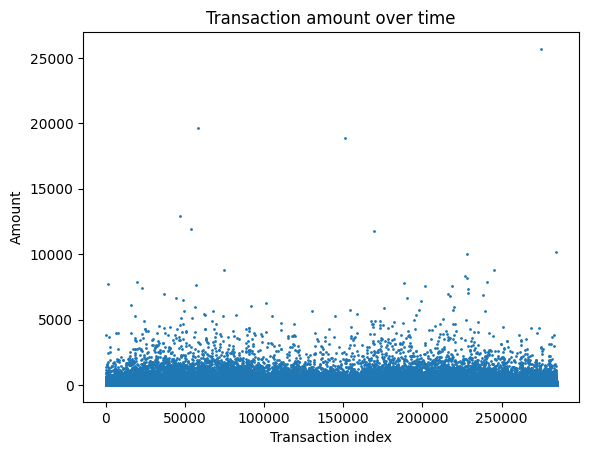

In [30]:
amounts = [x["Amount"] for x, _ in stream]
t = range(len(stream))

plt.figure()
plt.scatter(t, amounts, s=1)
plt.title("Transaction amount over time")
plt.xlabel("Transaction index")
plt.ylabel("Amount")
plt.show()

We observe:

- a high concentration of low-value transactions,
- occasional large spikes corresponding to high-value transactions,
- and no clear periodic or stationary pattern over time.

This indicates that the data stream is highly variable and potentially non-stationary, which poses challenges for anomaly detection algorithms.

### **Feature distribution**

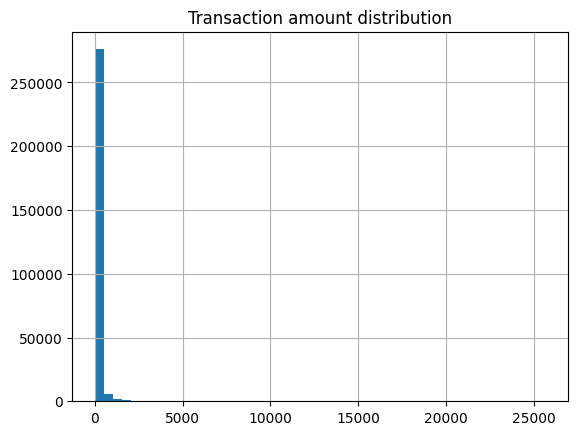

In [31]:
amounts = pd.Series([x["Amount"] for x, _ in stream])
amounts.hist(bins=50)
plt.title("Transaction amount distribution")
plt.show()

The distribution of transaction amounts is highly skewed, with the vast majority of transactions concentrated near very low values and a small number of extreme high-value transactions.

This heavy-tailed distribution indicates that:

- most observations belong to a dense region
- while a few points lie far from the bulk of the data.


> The presence of a heavy-tailed distribution means that large transaction values are naturally rare, which may cause density-based methods like LOF to incorrectly interpret them as anomalies.


### **PCA projection**

To better understand the structure of the high-dimensional data, we project the feature space into two dimensions using Principal Component Analysis (PCA).

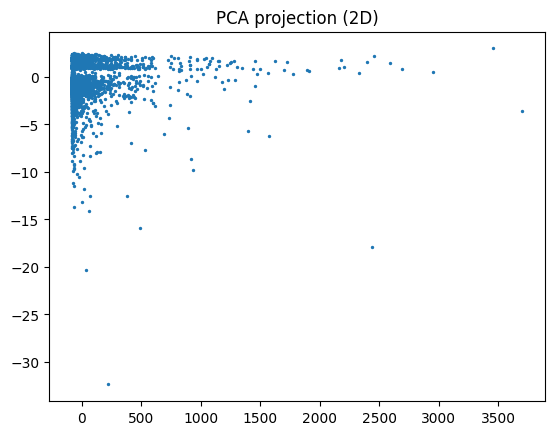

In [32]:


df_stream = pd.DataFrame([{**x, "Class": y} for x, y in stream])
features = df_stream.drop(columns=["Class"], errors="ignore")
pca = PCA(n_components=2)

X_pca = pca.fit_transform(features.sample(5000))

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=2)
plt.title("PCA projection (2D)")
plt.show()

To better understand the structure of the high-dimensional data, we project the feature space into two dimensions using Principal Component Analysis (PCA).

The resulting visualization shows a dense concentration of points near the origin, with a small number of points spread across the space.

This suggests that:

- most transactions share similar feature representations,
- while a few observations deviate from the main distribution,
- but no clearly separable clusters or boundaries are visible.

> The PCA projection highlights the lack of clear structure in the data, indicating that anomalies are not easily distinguishable based on simple geometric separation. This poses a significant challenge for density-based methods such as LOF, which rely on well-defined local neighborhoods.

### Conclusions from the Credit Card Dataset

The Credit Card dataset presents a much more challenging scenario than the synthetic data.

- The data is highly imbalanced, making accuracy unsuitable.
- The amount distribution is heavily skewed, meaning rare values are not necessarily anomalies.
- There is no clear temporal structure, so drift is subtle and hard to detect.
- The PCA projection shows no clear clusters, indicating strong overlap between normal and fraudulent transactions.

> Overall, anomalies are not clearly separable and must be detected through subtle patterns.


**Implications for the Algorithms**

- LOF may struggle because:
    - density differences are weak,
    - extreme values can cause false positives,
    - neighborhoods are less informative.

- HST is expected to be more robust:
    - less dependent on distance,
    - better suited for unstructured data.



So, The synthetic dataset tests assumptions in a controlled way, but is simplified.

The real dataset is necessary because it introduces:

- noise and overlap,
- subtle anomalies,
- and realistic imbalance.

> It validates whether conclusions from synthetic experiments hold in practice.



## **8. Implementation Setup**


The experiments were implemented in Python using the River library, which provides incremental algorithms designed for data stream mining. This makes it suitable for our setting, where data arrives sequentially and models must be updated online rather than trained in batch mode.  ￼  ￼

We evaluate two algorithms:

- Incremental LOF, used as the main algorithm of study
- Half-Space Trees (HST), used as the baseline comparison method  ￼

For Incremental LOF, the main parameter is:
- k (number of neighbors): controls how local density is estimated. Since LOF is sensitive to neighborhood definition, this is one of the key parameters in the study.  ￼

For Half-Space Trees, the main parameters are:
- number of trees: controls ensemble size
- tree depth: controls the granularity of the space partitioning

These parameters influence the stability, sensitivity, and computational cost of the baseline model.


In [ ]:
lof = anomaly.LocalOutlierFactor(n_neighbors=10)
hst = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

These initial values provide a reasonable starting point for comparison. Later experiments will further analyze the effect of the LOF parameter k, since it is directly related to one of the central hypotheses of this work.

## **9. Experiments**

In [22]:
synthetic_stream = generate_synthetic_stream()
df_synth = stream_to_df(synthetic_stream)

### **9.1 Prequential Evaluation Setup**

We evaluate the models using prequential evaluation, where each instance is processed sequentially following a predict → evaluate → update procedure.


In [11]:
def run_experiment(stream, model):
    roc_auc = metrics.ROCAUC()
    scores = []

    for item in stream:
        if len(item) == 2:
            x, y = item
        elif len(item) == 3:
            x, y, _ = item
        else:
            raise ValueError("Each stream item must be (x, y) or (x, y, phase)")

        score = model.score_one(x)
        roc_auc.update(y, score)
        scores.append(roc_auc.get())
        model.learn_one(x)

    return scores

### **9.2 Experiment 1: Baseline Comparison (H1 & H2)** 

We first compare Incremental LOF and Half-Space Trees on the same data stream to evaluate their overall performance.

In [ ]:
lof = anomaly.LocalOutlierFactor(n_neighbors=10)
hst = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

In [19]:
lof_scores = run_experiment(synthetic_stream, lof)
hst_scores = run_experiment(synthetic_stream, hst)

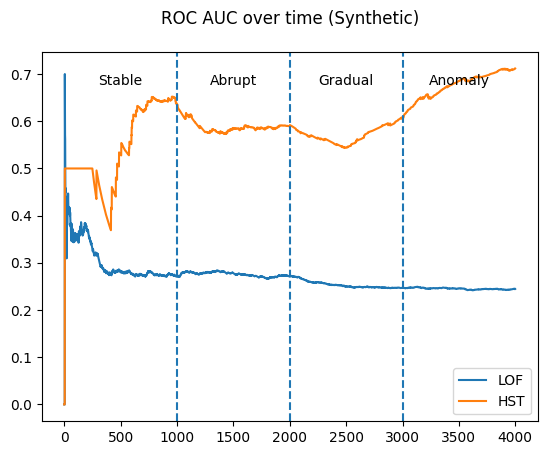

In [20]:
n = len(synthetic_stream)

p1 = n // 4
p2 = n // 2
p3 = 3 * n // 4


plt.figure()

plt.plot(lof_scores, label="LOF")
plt.plot(hst_scores, label="HST")

plt.axvline(p1, linestyle='--')
plt.axvline(p2, linestyle='--')
plt.axvline(p3, linestyle='--')

# Better label positioning
y_pos = max(max(lof_scores), max(hst_scores)) * 0.95

plt.text(p1/2, y_pos, "Stable", ha='center')
plt.text((p1+p2)/2, y_pos, "Abrupt", ha='center')
plt.text((p2+p3)/2, y_pos, "Gradual", ha='center')
plt.text((p3+n)/2, y_pos, "Anomaly", ha='center')

plt.title("ROC AUC over time (Synthetic)", pad=20)
plt.legend()
plt.show()

**Baseline Results (Synthetic Data)**
- LOF performs well only in the stable phase, then degrades after drift.
- Abrupt drift causes a sharp drop in LOF performance, with no recovery.
- Gradual drift further weakens LOF, due to unstable neighborhoods.
- HST remains stable and improves over time, adapting to distribution changes.
- In the anomaly phase, HST continues improving, while LOF remains low.

**Key Takeways**

> LOF is highly sensitive to drift, while HST provides more stable and adaptive performance in streaming settings.

> The performance drop of LOF aligns exactly with drift phases, confirming its reliance on stable local density structures.

### **9.3 Experiment 2A: Effect of k on Incremental LOF (H4)**

### **Goal**

This experiment evaluates how the choice of the neighborhood size k affects the performance of Incremental LOF on the synthetic stream.

This is important because LOF estimates anomaly scores from local density, and that density depends directly on the chosen neighborhood size:

- small k → very local, more sensitive, but noisier
- large k → smoother, more stable, but may hide local anomalies

Thus, this experiment directly tests the hypothesis that Incremental LOF is sensitive to k.



### **Experimental idea**

We run Incremental LOF several times on the same synthetic stream, changing only k, and track ROC AUC over time.

This allows us to observe:
- whether some values of k are clearly better than others
- whether small or large k values react differently to drift
- how robust LOF is to this parameter overal

**1. Helper function to create a fresh LOF model**

In [24]:
def make_lof(k):
    return anomaly.LocalOutlierFactor(n_neighbors=k)

**2. Run LOF for multiple k values**

Choose a range that is not too small and not too large. A good starting set is:

In [22]:
k_values = [5, 10, 20, 40]

In [23]:
k_results = {}

for k in k_values:
    lof_k = make_lof(k)
    k_results[k] = run_experiment(synthetic_stream, lof_k)

**3. Plot ROC AUC over time for each k**

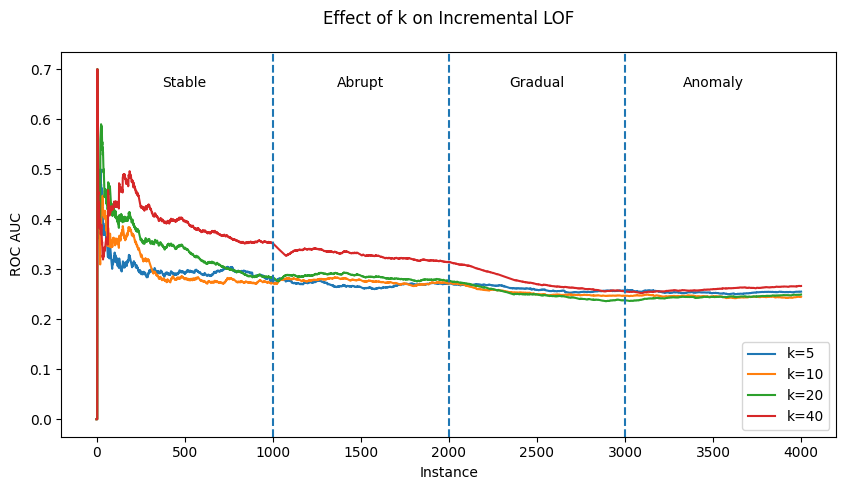

In [24]:
n = len(synthetic_stream)
p1 = n // 4
p2 = n // 2
p3 = 3 * n // 4

plt.figure(figsize=(10, 5))

for k, scores in k_results.items():
    plt.plot(scores, label=f"k={k}")

plt.axvline(p1, linestyle="--")
plt.axvline(p2, linestyle="--")
plt.axvline(p3, linestyle="--")

y_pos = max(max(scores) for scores in k_results.values()) * 0.95
plt.text(p1 / 2, y_pos, "Stable", ha="center")
plt.text((p1 + p2) / 2, y_pos, "Abrupt", ha="center")
plt.text((p2 + p3) / 2, y_pos, "Gradual", ha="center")
plt.text((p3 + n) / 2, y_pos, "Anomaly", ha="center")

plt.title("Effect of k on Incremental LOF", pad=20)
plt.xlabel("Instance")
plt.ylabel("ROC AUC")
plt.legend()
plt.show()

- k = 40 consistently performs best across all phases.
- Smaller k (5, 10) show more instability and lower overall performance.
- The performance gap is most visible in the stable and abrupt phases.
- After drift, all k values converge to similarly low performance (~0.25).

**4. Final ROC AUC by k**

In [25]:
final_k_scores = {k: scores[-1] for k, scores in k_results.items()}
final_k_scores

{5: np.float64(0.2551284744101379),
 10: np.float64(0.24483651893859837),
 20: np.float64(0.24939011139389214),
 40: np.float64(0.2664997258570037)}

In [26]:
df_k_summary = pd.DataFrame({
    "k": list(final_k_scores.keys()),
    "final_roc_auc": list(final_k_scores.values())
}).sort_values("k")

df_k_summary

,k,final_roc_auc
0,5,0.255128
1,10,0.244837
2,20,0.249390
3,40,0.266500


**Interpretation**

- Larger k improves stability
    - smoother density estimation reduces noise sensitivity
- Smaller k is too local
    - highly sensitive to small variations → unstable scores
- Drift dominates performance
    - even the best k (40) cannot recover after drift

**5. Best k**

In [27]:
best_k = max(final_k_scores, key=final_k_scores.get)
best_score = final_k_scores[best_k]

print(f"Best k: {best_k}")
print(f"Final ROC AUC: {best_score:.4f}")

Best k: 40
Final ROC AUC: 0.2665


**6. Phase-wise averages**

Here we do not only compare the final score, but also behavior in each phase.

In [28]:
def phase_means(scores):
    return {
        "stable": sum(scores[:p1]) / len(scores[:p1]),
        "abrupt": sum(scores[p1:p2]) / len(scores[p1:p2]),
        "gradual": sum(scores[p2:p3]) / len(scores[p2:p3]),
        "anomaly": sum(scores[p3:]) / len(scores[p3:])
    }

phase_summary = []

for k, scores in k_results.items():
    means = phase_means(scores)
    means["k"] = k
    phase_summary.append(means)

df_phase_summary = pd.DataFrame(phase_summary).sort_values("k")
df_phase_summary

,stable,abrupt,gradual,anomaly,k
0,0.302364,0.269610,0.261075,0.253884,5
1,0.302580,0.275768,0.253869,0.245379,10
2,0.343121,0.284409,0.251380,0.244172,20
3,0.391386,0.328776,0.276942,0.259905,40


**Increasing k improves LOF stability, but does not solve its fundamental limitation: poor adaptation to drift.**

> The results show that while k influences performance, all configurations of LOF converge to similarly low performance after drift, indicating that the main limitation lies in the density-based approach rather than parameter choice.

### **Experiment 2B: Isolating the Effect of k Under Mixed-Density Structure (H4)**

Although Experiment 3 showed that the choice of k affects LOF performance, the differences between values of k were moderate and all configurations remained weak after drift. This suggests that, in that setting, the dominant limitation of LOF was not parameter choice itself, but the inability to adapt to evolving distributions.

To better isolate the role of the neighborhood size parameter, we introduce a second controlled experiment in which drift is removed and the stream is designed so that anomaly detection depends strongly on local density structure. In this way, the effect of k can be studied more directly, without being masked by concept drift.

**Synthetic Dataset Generation**

We construct a stream composed of:

- a dense cluster
- a sparse cluster
- anomalies located between clusters or near the boundary of the sparse cluster

This setup ensures that anomaly detection depends strongly on how local density is estimated.

In [25]:
def generate_k_sensitive_stream(n_samples=4000, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    stream = []

    for _ in range(n_samples):
        r = random.random()

        # Dense normal cluster
        if r < 0.55:
            x = np.random.normal(loc=(0.0, 0.0), scale=0.20, size=2)
            y = 0
            phase = "dense"

        # Sparse normal cluster
        elif r < 0.85:
            x = np.random.normal(loc=(4.0, 0.0), scale=0.75, size=2)
            y = 0
            phase = "sparse"

        # Local anomalies: thin ring around dense cluster
        else:
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.normal(loc=0.75, scale=0.08)
            x1 = radius * np.cos(angle)
            x2 = radius * np.sin(angle)
            x = np.array([x1, x2])
            y = 1
            phase = "anomaly"

        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))

    return stream

In [4]:
def stream_to_df(stream):
    rows = []
    for x, y, phase in stream:
        rows.append({
            "x1": x["x1"],
            "x2": x["x2"],
            "label": y,
            "phase": phase
        })
    return pd.DataFrame(rows)

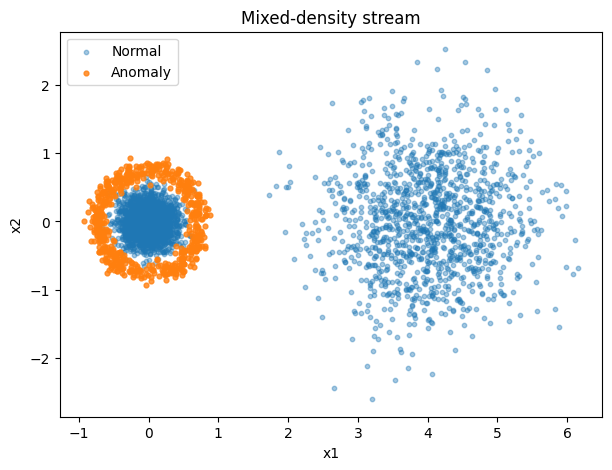

In [ ]:


stream_k_fixed = generate_k_sensitive_stream()
df_k_fixed = stream_to_df(stream_k_fixed)

plt.figure(figsize=(7, 5))

normal = df_k_fixed[df_k_fixed["label"] == 0]
anomaly = df_k_fixed[df_k_fixed["label"] == 1]

plt.scatter(normal["x1"], normal["x2"], s=10, alpha=0.4, label="Normal")
plt.scatter(anomaly["x1"], anomaly["x2"], s=12, alpha=0.8, label="Anomaly")

plt.title("Mixed-density stream")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

**Dataset structure**

- Dense cluster (center) → very high local density
- Ring anomalies → slightly farther, low-density relative to center
- Sparse cluster (right) → low density but legitimate

So anomaly detection depends on how neighborhoods mix these three regions

**Use a windowed ROC AUC**

In the previous version, cumulative ROC AUC made the curves converge visually. To better reveal the effect of k, we compute a windowed ROC AUC over the most recent observations.

In [10]:
def run_experiment_with_window(stream, model, window_size=300):
    cumulative_auc = metrics.ROCAUC()
    cumulative_scores = []

    y_window = deque(maxlen=window_size)
    score_window = deque(maxlen=window_size)
    windowed_scores = []

    for item in stream:
        if len(item) == 2:
            x, y = item
        elif len(item) == 3:
            x, y, _ = item
        else:
            raise ValueError("Each stream item must be (x, y) or (x, y, phase)")

        score = model.score_one(x)

        cumulative_auc.update(y, score)
        cumulative_scores.append(cumulative_auc.get())

        y_window.append(y)
        score_window.append(score)

        if len(y_window) == window_size and len(set(y_window)) > 1:
            auc_w = roc_auc_score(list(y_window), list(score_window))
            windowed_scores.append(auc_w)
        else:
            windowed_scores.append(np.nan)

        model.learn_one(x)

    return cumulative_scores, windowed_scores

**Run LOF with different values of k**

We now evaluate LOF for several values of k on exactly the same stream.

In [30]:
k_values = [3, 5, 10, 20, 40, 80]
k_results_fixed = {}

for k in k_values:
    lof_k = anomaly.LocalOutlierFactor(n_neighbors=k)
    cum_scores, win_scores = run_experiment_with_window(
        stream_k_fixed,
        lof_k,
        window_size=300
    )
    k_results_fixed[k] = {
        "cumulative": cum_scores,
        "windowed": win_scores
    }

**Plot the windowed ROC AUC**

This is the main plot for the corrected 3B, because it shows recent performance rather than a long-run average.

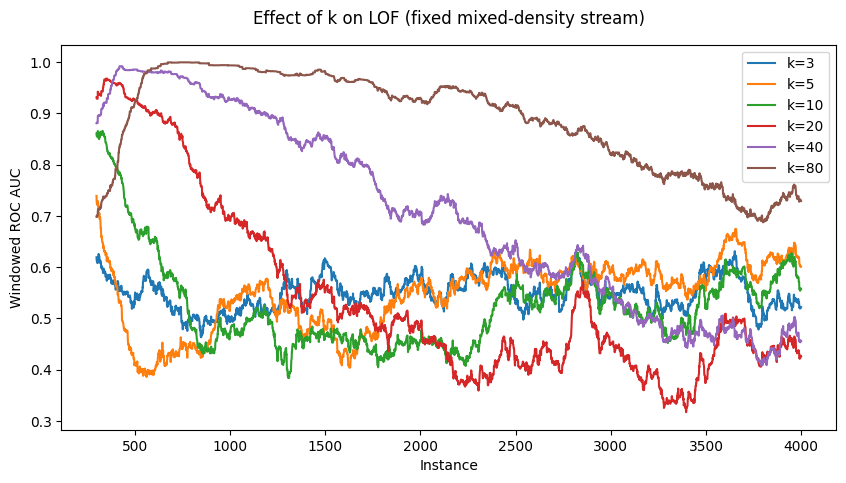

In [31]:
plt.figure(figsize=(10, 5))

for k in k_values:
    plt.plot(k_results_fixed[k]["windowed"], label=f"k={k}")

plt.title("Effect of k on LOF (fixed mixed-density stream)", pad=15)
plt.xlabel("Instance")
plt.ylabel("Windowed ROC AUC")
plt.legend()
plt.show()

**Plot cumulative ROC AUC as well**

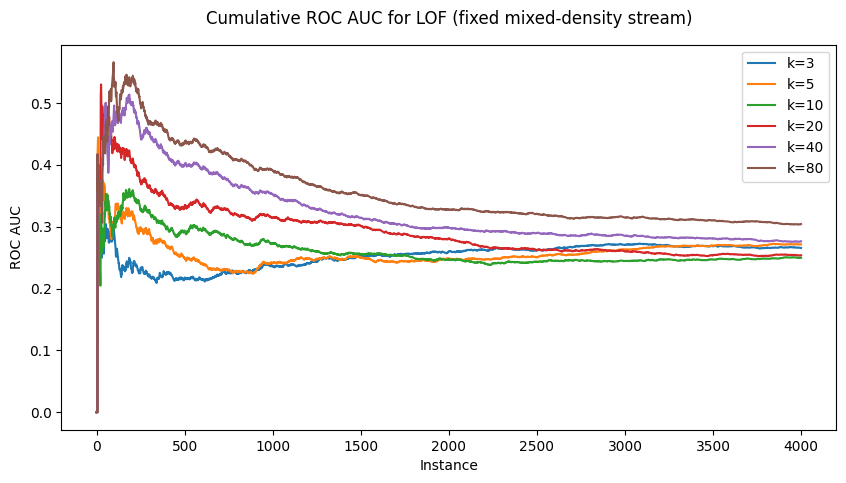

In [32]:
plt.figure(figsize=(10, 5))

for k in k_values:
    plt.plot(k_results_fixed[k]["cumulative"], label=f"k={k}")

plt.title("Cumulative ROC AUC for LOF (fixed mixed-density stream)", pad=15)
plt.xlabel("Instance")
plt.ylabel("ROC AUC")
plt.legend()
plt.show()

**Summarize the results in a table**

To compare configurations more clearly, we summarize both the final and average windowed ROC AUC.

In [33]:
summary_rows = []

for k in k_values:
    win_scores = np.array(k_results_fixed[k]["windowed"], dtype=float)
    valid_win_scores = win_scores[~np.isnan(win_scores)]

    summary_rows.append({
        "k": k,
        "final_cumulative_auc": k_results_fixed[k]["cumulative"][-1],
        "final_windowed_auc": valid_win_scores[-1] if len(valid_win_scores) else np.nan,
        "mean_windowed_auc": valid_win_scores.mean() if len(valid_win_scores) else np.nan
    })

df_k_fixed_summary = pd.DataFrame(summary_rows).sort_values("k")
df_k_fixed_summary

,k,final_cumulative_auc,final_windowed_auc,mean_windowed_auc
0,3,0.265689,0.522252,0.549007
1,5,0.271575,0.601238,0.546822
2,10,0.249737,0.557226,0.525656
3,20,0.253763,0.426172,0.543537
4,40,0.276450,0.455840,0.705121
5,80,0.304282,0.728952,0.887114


**Key observations**

- k = 80 clearly performs best, achieving the highest and most stable ROC AUC.
- k = 40 also performs well initially, but degrades over time.
- small k values (3–10) are unstable and consistently worse.

>The difference between k values is large and persistent, especially in windowed ROC AUC

>Small k keeps neighborhoods too local and fails to expose density differences, while large k creates cross-region comparisons that make anomalies clearly distinguishable

**Interpretation**

Large k improves stability and detection

- neighborhoods capture sufficient context
- anomalies (ring) are clearly low-density relative to neighbors

Small k is too local

- neighborhoods are noisy
- density estimates unstable
- weaker anomaly discrimination

Intermediate k (10–20) is not sufficient

- still too sensitive to local variation
- underperforms compared to large k

**Connection to previous experiments (H4 - 2a)**:

From the experiment 2A and 2B , we can see clear diffferences regarding the same issue ( k choice ):

Drift experiment:
- k matters little
- drift dominates → LOF fails

Corrected mixed-density experiment:
- k matters a lot
- locality dominates → LOF succeeds


> So, LOF is highly sensitive to k, but the importance of this parameter is context-dependent: it is critical when anomaly detection relies on local density structure, but has limited impact when drift dominates the data.



## **9.4 Local anomaly detection (H1)**



So far, the experiments have shown two important things.

- First, LOF struggles under drift, and changing k does not solve that limitation. Second, in a controlled mixed-density setting, the choice of k becomes critical, which confirms that LOF is highly dependent on how local neighborhoods are defined.

- However, these experiments focus mainly on limitations. To make the analysis balanced, we also need to test LOF in a setting where its assumptions hold clearly.

This motivates the next hypothesis:

**H1 — LOF performs better for local anomalies**

We include this hypothesis here because it answers an essential question for the whole project:

- If LOF fails under drift, is that because the algorithm is weak in general, or because it is being used in the wrong type of stream?

A dedicated local-anomaly experiment lets us show LOF in its intended scenario: a stationary stream where anomalies are not globally far away, but are unusual relative to their local neighborhood.

If LOF performs well here, then the notebook can make a much stronger final argument:

- LOF is not universally bad
- it is effective under the right assumptions
- but it becomes weak when those assumptions are violated

That makes the final discussion much more convincing.

**LOF for Local Anomalies**

We build a stationary synthetic stream with:

* two compact normal clusters
* anomalies placed in a narrow bridge between them

This is a good test for H1 because the anomalies are not necessarily extreme global outliers. Their abnormality comes from being in a locally low-density region between normal groups.

We compare:

* Incremental LOF
* Half-Space Trees

using the same prequential evaluation setup.

**Generate a local-anomaly stream**

In [ ]:


def generate_local_anomaly_stream(n_samples=4000, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    stream = []

    for _ in range(n_samples):
        r = random.random()

        # Normal points from two compact clusters
        if r < 0.90:
            center = random.choice([(0, 0), (4, 0)])
            x = np.random.normal(loc=center, scale=0.35, size=2)
            y = 0
            phase = "normal"

        # Local anomalies in the low-density bridge between clusters
        else:
            x = np.random.normal(loc=(2, 0), scale=0.18, size=2)
            y = 1
            phase = "anomaly"

        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))

    return stream

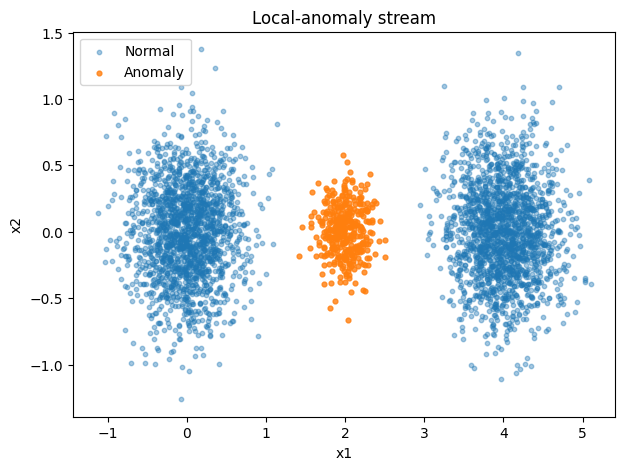

In [5]:

stream_h1 = generate_local_anomaly_stream()
df_h1 = stream_to_df(stream_h1)

plt.figure(figsize=(7, 5))

normal = df_h1[df_h1["label"] == 0]
anomaly = df_h1[df_h1["label"] == 1]

plt.scatter(normal["x1"], normal["x2"], s=10, alpha=0.4, label="Normal")
plt.scatter(anomaly["x1"], anomaly["x2"], s=12, alpha=0.8, label="Anomaly")

plt.title("Local-anomaly stream")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

**Create fresh models**

Use the best LOF configuration found in the previous experiment.

In [8]:
lof_h1 = anomaly.LocalOutlierFactor(n_neighbors=80)

hst_h1 = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

**Run the baseline comparison on the local-anomaly stream**


In [12]:
lof_h1_scores = run_experiment(stream_h1, lof_h1)
hst_h1_scores = run_experiment(stream_h1, hst_h1)

**Plot cumulative ROC AUC**

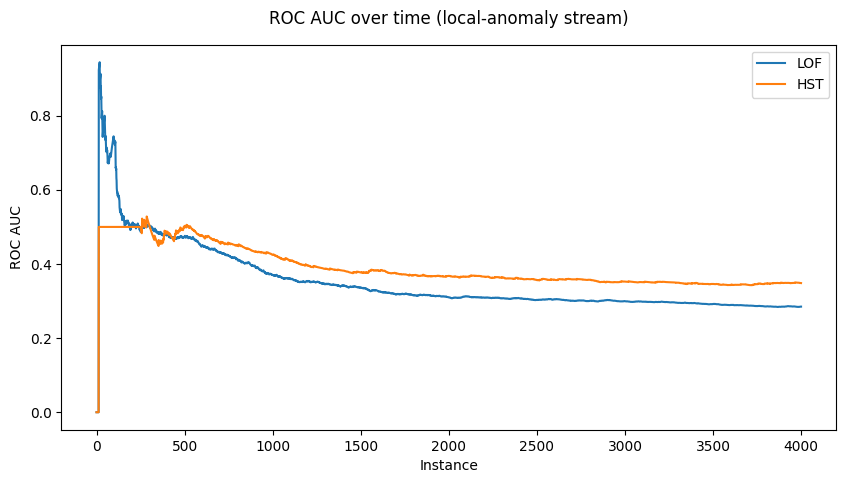

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(lof_h1_scores, label="LOF")
plt.plot(hst_h1_scores, label="HST")
plt.title("ROC AUC over time (local-anomaly stream)", pad=15)
plt.xlabel("Instance")
plt.ylabel("ROC AUC")
plt.legend()
plt.show()

**Windowed comparison**

In [14]:
lof_h1_w = anomaly.LocalOutlierFactor(n_neighbors=80)
hst_h1_w = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

_, lof_h1_windowed = run_experiment_with_window(stream_h1, lof_h1_w, window_size=300)
_, hst_h1_windowed = run_experiment_with_window(stream_h1, hst_h1_w, window_size=300)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(lof_h1_windowed, label="LOF")
plt.plot(hst_h1_windowed, label="HST")
plt.title("Windowed ROC AUC (local-anomaly stream)", pad=15)
plt.xlabel("Instance")
plt.ylabel("Windowed ROC AUC")
plt.legend()
plt.show()

In [ ]:
results_h1 = pd.DataFrame({
    "model": ["LOF", "HST"],
    "final_cumulative_auc": [lof_h1_scores[-1], hst_h1_scores[-1]],
    "final_windowed_auc": [
        np.array(lof_h1_windowed)[~np.isnan(lof_h1_windowed)][-1],
        np.array(hst_h1_windowed)[~np.isnan(hst_h1_windowed)][-1]
    ],
    "mean_windowed_auc": [
        np.array(lof_h1_windowed)[~np.isnan(lof_h1_windowed)].mean(),
        np.array(hst_h1_windowed)[~np.isnan(hst_h1_windowed)].mean()
    ]
})

results_h1

# TO DO :

# 9.5 Real dataset (validation)


# 9.6 Runtime & memory